<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/05_Lab_regresion_y_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio 4 — Regresión lineal y clasificación

## Cómo trabajar

* Las celdas marcadas con ✏️ **Ejercicio** tienen huecos `...` que usted debe completar.
* Después de cada ejercicio hay una celda ✅ **Checkpoint**: si corre sin errores, su implementación es correcta.
* Las demás celdas son de lectura y ejecución: córralas en orden, de arriba hacia abajo.

**Duración estimada:** 3 horas. **Entregable:** este mismo notebook ejecutado + las respuestas de la sección final.

## 0. Preparación

Ejecute esta celda una sola vez.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

rng = np.random.default_rng(42)
print("Listo. numpy", np.__version__)

Listo. numpy 2.1.3


### La receta de 5 pasos

Todo lo que sigue —regresión lineal, multivariada y clasificación— es la **misma receta** con piezas distintas:

| Paso | Qué se elige | Regresión lineal | Regresión logística |
|---|---|---|---|
| 1 | Hipótesis $h_\Theta(X)$ | $\Theta^T X$ | $\sigma(\Theta^T X)$ |
| 2 | Función de coste $J(\Theta)$ | error cuadrático | entropía cruzada |
| 3 | Gradiente $\nabla_\Theta J$ | $\frac{1}{m}X^T(h-y)$ | $\frac{1}{m}X^T(h-y)$ |
| 4 | Optimizador | gradiente descendente / ecuación normal | gradiente descendente |
| 5 | Evaluación | $J$, $R^2$ | exactitud, curvas de aprendizaje |

Fíjese desde ya en la fila 3: **el gradiente tiene exactamente la misma forma en los dos modelos**. Volveremos a esto en la Parte 6.

> *Non-Free-Lunch Theorem*: no existe un algoritmo universalmente mejor. Siempre conviene inyectar conocimiento del problema.

---
# Parte 1 — Una característica: hipótesis y función de coste

Tenemos $m$ pares de entrenamiento $(x^{(1)},y^{(1)}),\dots,(x^{(m)},y^{(m)})$ y proponemos la hipótesis lineal

$$h_\theta(x) = \theta_0 + \theta_1 x$$

La calidad del ajuste se mide con la **función de coste** (métrica euclidiana):

$$J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)^2$$

Entrenar = **encontrar el mínimo de $J$**.

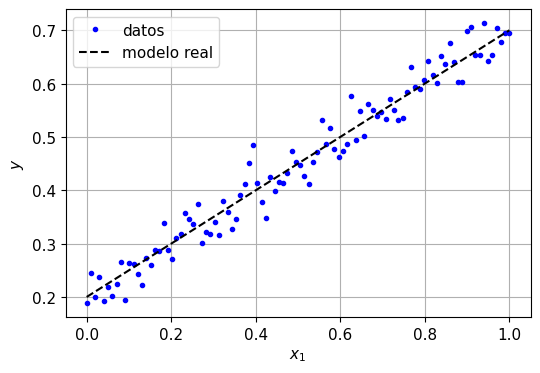

In [ ]:
# Datos sintéticos: conocemos la respuesta (theta_0 = 0.2, theta_1 = 0.5)
m = 100
X = np.linspace(0, 1, m)
theta_real = (0.2, 0.5)
y = theta_real[0] + theta_real[1] * X + rng.normal(0, 0.03, m)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.", label="datos")
plt.plot(X, theta_real[0] + theta_real[1] * X, "k--", label="modelo real")
plt.xlabel("$x_1$"); plt.ylabel("$y$"); plt.legend(); plt.show()

In [ ]:
def H(X, t0, t1):
    """Hipótesis lineal h(x) = t0 + t1*x."""
    return t0 + t1 * X


def J(t0, t1, X, y):
    """Función de coste (error cuadrático medio / 2)."""
    return ((H(X, t0, t1) - y) ** 2).mean() / 2


print("J en el óptimo teórico:", round(J(*theta_real, X, y), 6))
print("J en un punto malo   :", round(J(0.0, 3.0, X, y), 6))

J en el óptimo teórico: 0.000427
J en un punto malo   : 0.81604


### ✏️ Ejercicio 1.1 — Barrido de $\theta_1$

Fije $\theta_0 = 0.2$ y evalúe $J$ sobre una malla de valores de $\theta_1$. Complete la línea marcada.

In [ ]:
t1_grid = np.linspace(-1, 2, 300)

# Evalúe J(0.2, t1, X, y) para cada t1 de t1_grid
J_grid = np.array([J(0.2, t1, X, y) for t1 in t1_grid])

t1_opt = t1_grid[np.argmin(J_grid)]
print("theta_1 que minimiza J:", round(t1_opt, 4))

theta_1 que minimiza J: 0.505


In [ ]:
# ✅ Checkpoint 1.1
assert np.shape(J_grid) == (300,), "J_grid debe tener un valor por cada theta_1"
assert abs(t1_opt - theta_real[1]) < 0.05, "el mínimo no coincide con la pendiente real"
print("Correcto ✔")

Correcto ✔


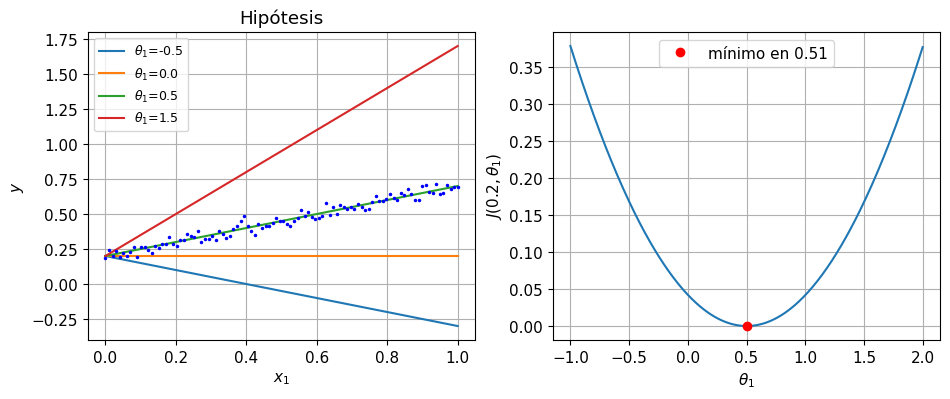

In [ ]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
for t1 in [-0.5, 0.0, 0.5, 1.5]:
    plt.plot(X, H(X, 0.2, t1), label=f"$\\theta_1$={t1}")
plt.plot(X, y, "b.", ms=3)
plt.xlabel("$x_1$"); plt.ylabel("$y$"); plt.legend(fontsize=9); plt.title("Hipótesis")

plt.subplot(122)
plt.plot(t1_grid, J_grid)
plt.plot(t1_opt, J_grid.min(), "ro", label=f"mínimo en {t1_opt:.2f}")
plt.xlabel("$\\theta_1$"); plt.ylabel("$J(0.2,\\theta_1)$"); plt.legend(); plt.show()

### La superficie de coste

Con dos parámetros, $J$ es una **superficie** en $\mathbb{R}^3$ y el entrenamiento consiste en bajar hasta su fondo. Para el error cuadrático esa superficie es un paraboloide: **convexa**, con un único mínimo global.

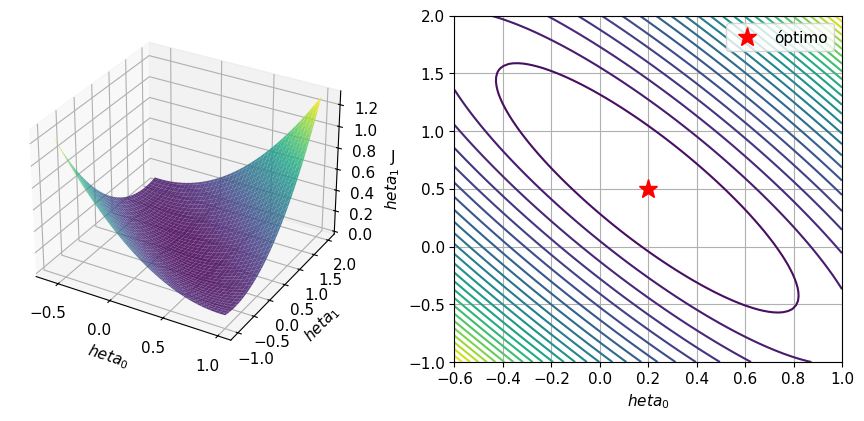

In [ ]:
t0g, t1g = np.meshgrid(np.linspace(-0.6, 1.0, 80), np.linspace(-1.0, 2.0, 80))
Jg = np.array([[J(a, b, X, y) for a, b in zip(fa, fb)] for fa, fb in zip(t0g, t1g)])

fig = plt.figure(figsize=(11, 4.5))
ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(t0g, t1g, Jg, cmap="viridis", alpha=0.85)
ax.set_xlabel(r"$	heta_0$"); ax.set_ylabel(r"$	heta_1$"); ax.set_zlabel("J")

ax2 = fig.add_subplot(122)
cs = ax2.contour(t0g, t1g, Jg, 30, cmap="viridis")
ax2.plot(*theta_real, "r*", ms=14, label="óptimo")
ax2.set_xlabel(r"$	heta_0$"); ax2.set_ylabel(r"$	heta_1$"); ax2.legend()
plt.show()

---
# Parte 2 — Gradiente descendente

Para bajar por la superficie usamos la regla de actualización

$$\theta_j := \theta_j - \alpha\,\frac{\partial J}{\partial \theta_j}$$

donde $\alpha$ es la **tasa de aprendizaje**. Primero, la intuición en 1D con $f(w)=(w-1)^2$, cuyo mínimo está en $w=1$.

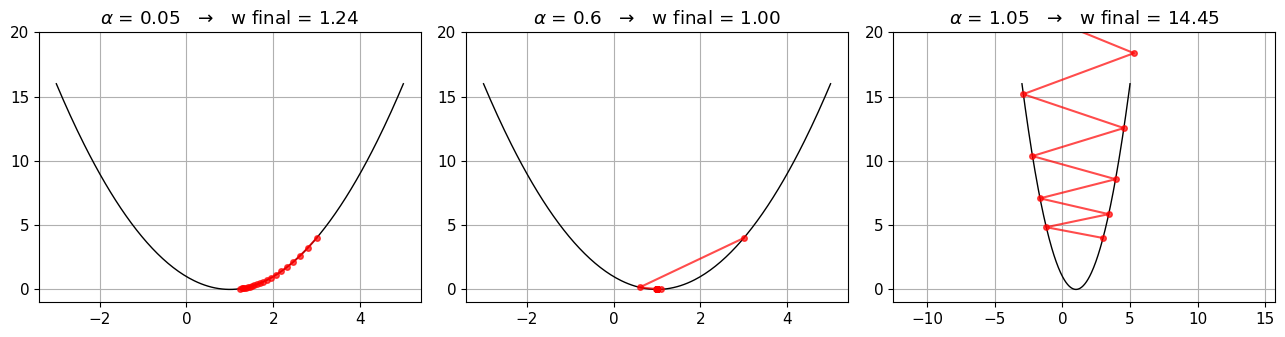

In [ ]:
f  = lambda w: (w - 1) ** 2
fp = lambda w: 2 * (w - 1)


def descenso_1d(w0, alpha, n_iter=20):
    w, hist = w0, [w0]
    for _ in range(n_iter):
        w = w - alpha * fp(w)
        hist.append(w)
    return np.array(hist)


w = np.linspace(-3, 5, 200)
plt.figure(figsize=(13, 3.5))
for k, alpha in enumerate([0.05, 0.6, 1.05]):
    hist = descenso_1d(3.0, alpha)
    plt.subplot(1, 3, k + 1)
    plt.plot(w, f(w), "k-", lw=1)
    plt.plot(hist, f(hist), "ro-", ms=4, alpha=0.7)
    plt.title(f"$\\alpha$ = {alpha}   →   w final = {hist[-1]:.2f}")
    plt.ylim(-1, 20)
plt.tight_layout(); plt.show()

Los tres casos resumen todo lo que puede pasar:

* $\alpha$ **muy pequeño**: converge, pero gasta demasiadas iteraciones.
* $\alpha$ **adecuado**: baja rápido y se queda en el mínimo.
* $\alpha$ **muy grande**: sobrepasa el mínimo en cada paso y **diverge**.

Para nuestra función de coste las derivadas parciales son:

$$\frac{\partial J}{\partial\theta_0}=\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right),
\qquad
\frac{\partial J}{\partial\theta_1}=\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)x^{(i)}$$

### ✏️ Ejercicio 2.1 — Implemente el gradiente y el descenso

In [ ]:
def grad_J(t0, t1, X, y):
    """Devuelve (dJ/dtheta_0, dJ/dtheta_1)."""

    err = H(X, t0, t1) - y

    d0 = err.mean()
    d1 = (err * X).mean()

    return d0, d1


def descenso(X, y, alpha=0.5, n_iter=3000, t0=0.0, t1=0.0):

    hist = []

    for _ in range(n_iter):

        d0, d1 = grad_J(t0, t1, X, y)

        t0 = t0 - alpha * d0
        t1 = t1 - alpha * d1

        hist.append((t0, t1, J(t0, t1, X, y)))

    return t0, t1, np.array(hist)


t0_gd, t1_gd, hist = descenso(X, y)

print(f"theta_0 = {t0_gd:.4f}   theta_1 = {t1_gd:.4f}   (reales: {theta_real})")

theta_0 = 0.1958   theta_1 = 0.5078   (reales: (0.2, 0.5))


In [ ]:
# ✅ Checkpoint 2.1 — comparamos contra el ajuste de numpy
p1, p0 = np.polyfit(X, y, 1)
assert abs(t0_gd - p0) < 1e-2 and abs(t1_gd - p1) < 1e-2, "el descenso no llegó al óptimo"
assert hist[-1, 2] < hist[0, 2], "el coste debería disminuir"
print(f"Correcto ✔  (numpy: theta_0={p0:.4f}, theta_1={p1:.4f})")

Correcto ✔  (numpy: theta_0=0.1958, theta_1=0.5078)


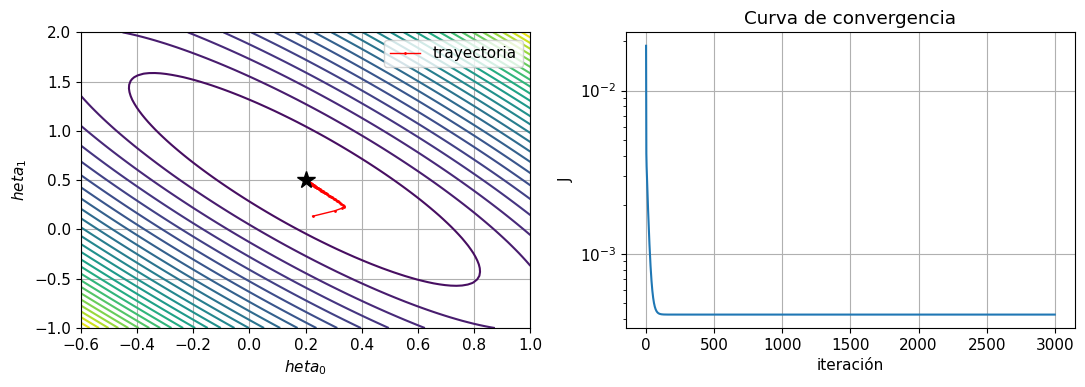

In [ ]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.contour(t0g, t1g, Jg, 30, cmap="viridis")
plt.plot(hist[:, 0], hist[:, 1], "r.-", ms=2, lw=1, label="trayectoria")
plt.plot(*theta_real, "k*", ms=13)
plt.xlabel(r"$	heta_0$"); plt.ylabel(r"$	heta_1$"); plt.legend()

plt.subplot(122)
plt.semilogy(hist[:, 2])
plt.xlabel("iteración"); plt.ylabel("J"); plt.title("Curva de convergencia")
plt.tight_layout(); plt.show()

**Pregunta guía.** Vuelva a correr `descenso` con `alpha=3.0` y con `alpha=0.01`. ¿Qué observa en la curva de convergencia en cada caso?

---
# Parte 3 — Regresión multivariada (versión vectorizada)

Con $n$ características, escribimos todo en forma matricial. Añadimos una columna de unos para el intercepto:

$$X=\begin{bmatrix}1 & x_1^{(1)} & \cdots & x_n^{(1)}\\ \vdots & & & \vdots\\ 1 & x_1^{(m)} & \cdots & x_n^{(m)}\end{bmatrix}_{m\times(n+1)},\qquad \Theta=\begin{bmatrix}\theta_0\\ \vdots\\ \theta_n\end{bmatrix}$$

$$h = X\Theta,\qquad J(\Theta)=\frac{1}{2m}\,(h-y)^T(h-y),\qquad \nabla_\Theta J = \frac{1}{m}X^T(h-y)$$

Los bucles de la Parte 2 desaparecen: todo son tres productos matriciales.

In [ ]:
def agregar_sesgo(Xf):
    """(m, n) -> (m, n+1) agregando una columna de unos al frente."""
    Xf = np.asarray(Xf, dtype=float)
    if Xf.ndim == 1:
        Xf = Xf.reshape(-1, 1)
    return np.hstack([np.ones((Xf.shape[0], 1)), Xf])


def h_lin(Theta, Xb):
    return Xb @ Theta


def J_lin(Theta, Xb, y):
    r = h_lin(Theta, Xb) - y
    return (r @ r) / (2 * len(y))

### ✏️ Ejercicio 3.1 — El gradiente vectorizado

Traduzca $\nabla_\Theta J = \frac{1}{m}X^T(h-y)$ a una sola línea de numpy.

In [ ]:
def grad_lin(Theta, Xb, y):

    m = len(y)

    return Xb.T @ (h_lin(Theta, Xb) - y) / m


def descenso_vec(Xb, y, alpha=0.1, n_iter=5000, Theta=None):

    Theta = np.zeros(Xb.shape[1]) if Theta is None else np.array(Theta, dtype=float)

    hist = []

    for _ in range(n_iter):

        Theta = Theta - alpha * grad_lin(Theta, Xb, y)

        hist.append(J_lin(Theta, Xb, y))

    return Theta, np.array(hist)

In [ ]:
# ✅ Checkpoint 3.1 — verificación numérica del gradiente
# Comparamos su fórmula contra una derivada numérica: es la mejor forma
# de detectar errores de signo o de transposición.
def grad_numerico(fun, Theta, eps=1e-6):
    g = np.zeros_like(Theta)
    for k in range(len(Theta)):
        e = np.zeros_like(Theta); e[k] = eps
        g[k] = (fun(Theta + e) - fun(Theta - e)) / (2 * eps)
    return g


Xb_test = agregar_sesgo(rng.normal(size=(30, 3)))
y_test = rng.normal(size=30)
Th_test = rng.normal(size=4)

g_ana = grad_lin(Th_test, Xb_test, y_test)
g_num = grad_numerico(lambda T: J_lin(T, Xb_test, y_test), Th_test)
assert np.allclose(g_ana, g_num, atol=1e-6), "el gradiente analítico no coincide con el numérico"
print("Correcto ✔  gradiente analítico == gradiente numérico")

Correcto ✔  gradiente analítico == gradiente numérico


Theta estimado: [-1.0021  0.1951  0.5027]    (real: [-1, 0.2, 0.5])


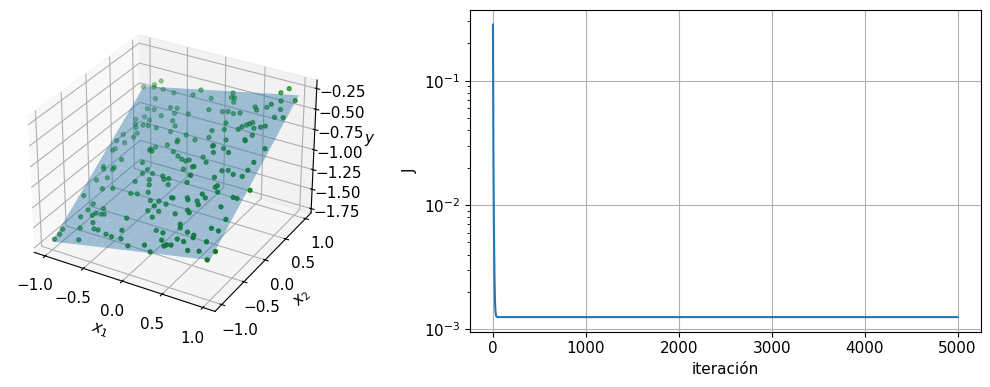

In [ ]:
# Datos: un plano  y = -1 + 0.2*x1 + 0.5*x2  con ruido
N = 200
x1 = rng.uniform(-1, 1, N)
x2 = rng.uniform(-1, 1, N)
y2 = -1.0 + 0.2 * x1 + 0.5 * x2 + rng.normal(0, 0.05, N)

Xb = agregar_sesgo(np.column_stack([x1, x2]))
Theta_gd, hist2 = descenso_vec(Xb, y2, alpha=0.3, n_iter=5000)
print("Theta estimado:", np.round(Theta_gd, 4), "   (real: [-1, 0.2, 0.5])")

fig = plt.figure(figsize=(11, 4))
ax = fig.add_subplot(121, projection="3d")
g1, g2 = np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20))
ax.plot_surface(g1, g2, Theta_gd[0] + Theta_gd[1] * g1 + Theta_gd[2] * g2, alpha=0.4)
ax.scatter(x1, x2, y2, c="g", s=8)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$y$")

ax2 = fig.add_subplot(122)
ax2.semilogy(hist2); ax2.set_xlabel("iteración"); ax2.set_ylabel("J")
plt.tight_layout(); plt.show()

---
# Parte 4 — Escalamiento de características

¿Qué pasa si una característica vive en $[-1,1]$ y otra en $[-2000,2000]$? La superficie de coste se vuelve un valle largo y estrecho: el mismo $\alpha$ es demasiado grande en una dirección y demasiado pequeño en la otra.

La solución es **estandarizar**:

$$x_j \leftarrow \frac{x_j-\mu_j}{s_j}$$

con $\mu_j$ la media y $s_j$ la desviación estándar (o el rango) de la característica $j$.

In [ ]:
# Sin escalar: x2 tiene un rango 2000 veces mayor que x1
n = 100
z1 = rng.uniform(-1, 1, n)
z2 = rng.uniform(-2000, 2000, n)
yz = 2 * z1 - 3 * z2 + rng.normal(0, 0.1, n)

Xb_mal = agregar_sesgo(np.column_stack([z1, z2]))
with np.errstate(over="ignore", invalid="ignore"):
    _, hist_mal = descenso_vec(Xb_mal, yz, alpha=0.3, n_iter=30)

print("Coste en las 5 primeras iteraciones:", hist_mal[:5])
print("Coste tras 30 iteraciones          :", hist_mal[-1], " ← diverge")
print()
print("Con alpha mucho más pequeño tampoco es buena idea:")
with np.errstate(over="ignore", invalid="ignore"):
    Th_mal, h2 = descenso_vec(Xb_mal, yz, alpha=1e-8, n_iter=2000)
print("  alpha=1e-8, 2000 iteraciones -> Theta =", np.round(Th_mal, 3), " (real: [0, 2, -3])")
print("  el coeficiente de x2 ya está, pero el de x1 ni se ha movido")

Coste en las 5 primeras iteraciones: [1.46663268e+18 3.11251564e+29 6.60543962e+40 1.40181890e+52
 2.97496662e+63]
Coste tras 30 iteraciones          : inf  ← diverge

Con alpha mucho más pequeño tampoco es buena idea:
  alpha=1e-8, 2000 iteraciones -> Theta = [-0.  0. -3.]  (real: [0, 2, -3])
  el coeficiente de x2 ya está, pero el de x1 ni se ha movido


### ✏️ Ejercicio 4.1 — Estandarice y vuelva a entrenar

In [ ]:
def estandarizar(Xf):
    """Devuelve (X escalado, mu, sigma) columna por columna."""

    Xf = np.asarray(Xf, dtype=float)

    mu = Xf.mean(axis=0)
    sigma = Xf.std(axis=0)

    return (Xf - mu) / sigma, mu, sigma


Z = np.column_stack([z1, z2])

Z_esc, mu, sigma = estandarizar(Z)

Xb_bien = agregar_sesgo(Z_esc)

Theta_esc, hist_bien = descenso_vec(Xb_bien, yz, alpha=0.3, n_iter=2000)

print("Coste final tras escalar:", round(hist_bien[-1], 4))

Coste final tras escalar: 0.0053


In [ ]:
# ✅ Checkpoint 4.1
assert np.allclose(Z_esc.mean(axis=0), 0, atol=1e-10), "la media escalada debe ser 0"
assert np.allclose(Z_esc.std(axis=0), 1, atol=1e-10), "la desviación escalada debe ser 1"
assert np.isfinite(hist_bien[-1]) and hist_bien[-1] < 10, "el descenso aún no converge"
print("Correcto ✔")

# Los parámetros escalados se devuelven al espacio original así:
t_orig = Theta_esc[1:] / sigma
t0_orig = Theta_esc[0] - (Theta_esc[1:] * mu / sigma).sum()
print("Coeficientes en unidades originales:", np.round([t0_orig, *t_orig], 3), " (real: [0, 2, -3])")

Correcto ✔
Coeficientes en unidades originales: [ 0.005  2.012 -3.   ]  (real: [0, 2, -3])


---
# Parte 5 — La ecuación normal

Para el error cuadrático **no hace falta iterar**: el mínimo tiene solución cerrada. Partiendo de

$$J(\Theta)=\frac{1}{2m}(X\Theta-y)^T(X\Theta-y),\qquad \nabla_\Theta J=\frac{1}{m}\left(X^TX\,\Theta-X^Ty\right)$$

e imponiendo $\nabla_\Theta J = 0$:

$$\boxed{\;\Theta=(X^TX)^{-1}X^Ty\;}$$

*(La demostración completa queda como tarea; use $\nabla_x b^Tx=b$ y $\nabla_x x^TAx=2Ax$ con $A$ simétrica.)*

**Nota práctica:** nunca invierta la matriz explícitamente. `np.linalg.solve(A, b)` resuelve $A\Theta=b$ y es más estable y rápido que `np.linalg.inv(A) @ b`.

### ✏️ Ejercicio 5.1 — Implemente la ecuación normal

In [ ]:
def ecuacion_normal(Xb, y):
    """Theta = (X^T X)^{-1} X^T y, resuelto con np.linalg.solve."""

    A = Xb.T @ Xb
    b = Xb.T @ y

    return np.linalg.solve(A, b)


Theta_ne = ecuacion_normal(Xb, y2)

print("Ecuación normal   :", np.round(Theta_ne, 4))
print("Gradiente desc.   :", np.round(Theta_gd, 4))

Ecuación normal   : [-1.0021  0.1951  0.5027]
Gradiente desc.   : [-1.0021  0.1951  0.5027]


In [ ]:
# ✅ Checkpoint 5.1
assert np.allclose(Theta_ne, Theta_gd, atol=1e-3), "los dos métodos deberían coincidir"
assert J_lin(Theta_ne, Xb, y2) <= J_lin(Theta_gd, Xb, y2) + 1e-9, "la solución cerrada es la óptima"
print("Correcto ✔  ambos métodos llegan al mismo mínimo")

Correcto ✔  ambos métodos llegan al mismo mínimo


In [ ]:
# Datos reales: diabetes (442 pacientes, 10 características)
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

datos = load_diabetes()
Xd, yd = datos.data, datos.target
Xdb = agregar_sesgo(Xd)

Theta_d = ecuacion_normal(Xdb, yd)
skl = LinearRegression().fit(Xd, yd)

print("Nuestro intercepto :", round(Theta_d[0], 4), "  sklearn:", round(skl.intercept_, 4))
print("Máxima diferencia en los coeficientes:", np.abs(Theta_d[1:] - skl.coef_).max())

r2 = 1 - ((Xdb @ Theta_d - yd) ** 2).sum() / ((yd - yd.mean()) ** 2).sum()
print("R^2 =", round(r2, 4))

Nuestro intercepto : 152.1335   sklearn: 152.1335
Máxima diferencia en los coeficientes: 1.7621459846850485e-12
R^2 = 0.5177


### ¿Gradiente descendente o ecuación normal?

| | Gradiente descendente | Ecuación normal |
|---|---|---|
| Hiperparámetros | requiere elegir $\alpha$ y n.º de iteraciones | ninguno |
| Escalamiento | imprescindible | innecesario |
| Costo | $O(k\,n^2)$ | $O(n^3)$ por la inversión |
| $n$ grande ($>10^4$) | funciona bien | se vuelve inviable |
| Otros modelos | sirve para logística, redes, etc. | solo mínimos cuadrados |

### ¿Por qué mínimos cuadrados y no otra métrica?

Si suponemos $y^{(i)}=\Theta^TX^{(i)}+\epsilon_i$ con $\epsilon_i\sim\mathcal{N}(0,\sigma^2)$ i.i.d., la verosimilitud es

$$\mathcal{L}(\Theta)=\prod_{i=1}^{m}\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(y^{(i)}-\Theta^TX^{(i)})^2}{2\sigma^2}}
\;\Longrightarrow\;
\ell(\Theta)=\text{cte}-\frac{1}{2\sigma^2}\sum_{i=1}^{m}\left(y^{(i)}-\Theta^TX^{(i)}\right)^2$$

Maximizar $\ell$ es **exactamente** minimizar el error cuadrático. Los mínimos cuadrados son el estimador de máxima verosimilitud bajo ruido gaussiano; si el ruido no es gaussiano, otra métrica puede ser mejor.

---
# Parte 6 — Clasificación: regresión logística

Ahora $y\in\{0,1\}$. Queremos que la salida sea una **probabilidad**, así que pasamos $\Theta^TX$ por la sigmoide:

$$h_\Theta(X)=\sigma(\Theta^TX)=\frac{1}{1+e^{-\Theta^TX}}=P(y=1\mid X;\Theta),
\qquad \sigma'(z)=\sigma(z)\,(1-\sigma(z))$$

La regla de decisión es simplemente el signo del argumento:

* $\Theta^TX \ge 0 \Rightarrow h \ge 0.5 \Rightarrow$ clase 1
* $\Theta^TX < 0 \Rightarrow h < 0.5 \Rightarrow$ clase 0

La ecuación $\Theta^TX = 0$ define la **frontera de decisión**.

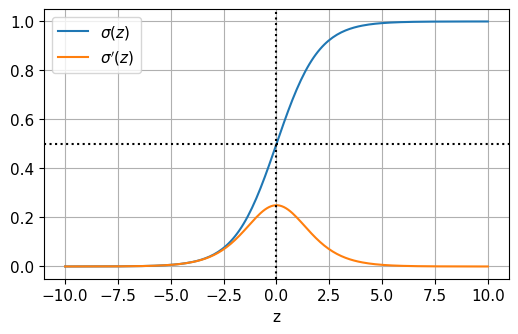

In [ ]:
sigmoide = lambda z: 1 / (1 + np.exp(-z))
z = np.linspace(-10, 10, 200)

plt.figure(figsize=(6, 3.5))
plt.plot(z, sigmoide(z), label=r"$\sigma(z)$")
plt.plot(z, sigmoide(z) * (1 - sigmoide(z)), label=r"$\sigma'(z)$")
plt.axhline(0.5, color="k", ls=":"); plt.axvline(0, color="k", ls=":")
plt.xlabel("z"); plt.legend(); plt.show()

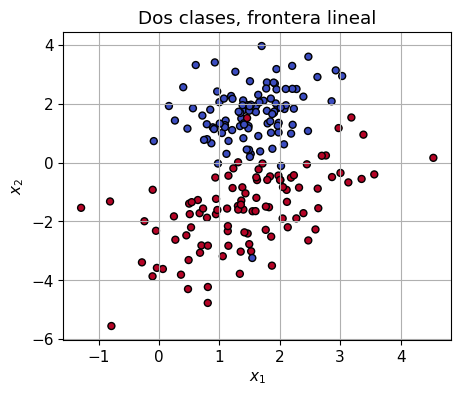

In [ ]:
from sklearn.datasets import make_classification, make_circles

Xc, yc = make_classification(n_samples=200, n_features=2, n_redundant=0,
                             n_informative=2, n_clusters_per_class=1,
                             class_sep=1.5, random_state=1)

plt.figure(figsize=(5, 4))
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k", s=25)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("Dos clases, frontera lineal")
plt.show()

### Fronteras no lineales

Nada obliga a que $\Theta^TX$ sea lineal en las características originales. Si agregamos términos polinómicos, por ejemplo

$$\theta_0+\theta_1x_1+\theta_2x_2+\theta_3x_1^2+\theta_4x_2^2 \ge 0,$$

la frontera puede ser una circunferencia, una elipse, etc.

### ✏️ Ejercicio 6.1 — Encuentre la frontera circular

Para los datos de `make_circles`, con $\Theta=[-r^2,\,0,\,0,\,1,\,1]$ la frontera es $x_1^2+x_2^2=r^2$. Busque el radio $r$ que mejor separa las clases.

In [ ]:
Xr, yr = make_circles(
    n_samples=300,
    factor=0.5,
    noise=0.05,
    random_state=0
)

# En make_circles la clase 1 es el círculo interior.

def clasifica_circulo(Xf, r):
    """Devuelve 1 si el punto está dentro del círculo de radio r."""
    return (Xf[:, 0]**2 + Xf[:, 1]**2 <= r**2).astype(int)


radios = np.linspace(0.2, 1.0, 100)

exactitudes = np.array([
    (clasifica_circulo(Xr, r) == yr).mean()
    for r in radios
])

r_opt = radios[np.argmax(exactitudes)]

print(
    f"Radio óptimo = {r_opt:.3f}   "
    f"exactitud = {exactitudes.max():.3f}"
)

Radio óptimo = 0.636   exactitud = 1.000


Correcto ✔


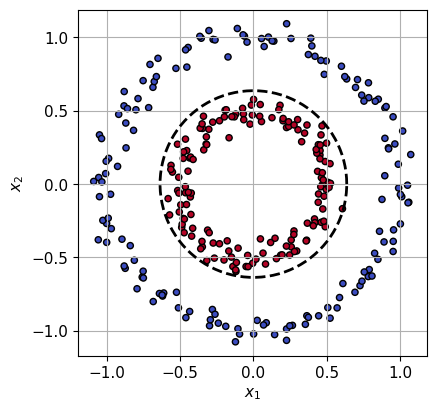

In [ ]:
# ✅ Checkpoint 6.1
assert exactitudes.max() > 0.95, "debería poder separar los anillos casi perfectamente"
print("Correcto ✔")

ang = np.linspace(0, 2 * np.pi, 200)
plt.figure(figsize=(4.5, 4.5))
plt.scatter(Xr[:, 0], Xr[:, 1], c=yr, cmap="coolwarm", edgecolor="k", s=20)
plt.plot(r_opt * np.cos(ang), r_opt * np.sin(ang), "k--", lw=2)
plt.axis("equal"); plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.show()

### Función de coste: entropía cruzada

El error cuadrático no sirve aquí (produce una superficie con múltiples mínimos locales). Se usa

$$J(\Theta)=-\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log h_\Theta(X^{(i)})+(1-y^{(i)})\log\left(1-h_\Theta(X^{(i)})\right)\right]$$

que penaliza fuertemente predecir con confianza la clase equivocada. Y aquí está el resultado elegante del laboratorio: su gradiente es

$$\nabla_\Theta J=\frac{1}{m}X^T\left(h_\Theta(X)-y\right)$$

**idéntico en forma al de la regresión lineal**; lo único que cambia es la definición de $h$. (Sale de $\sigma'=\sigma(1-\sigma)$ y de la regla de la cadena.)

### ✏️ Ejercicio 6.2 — Entrene un clasificador desde cero

In [ ]:
def h_log(Theta, Xb):
    return sigmoide(Xb @ Theta)


def J_log(Theta, Xb, y, eps=1e-12):
    p = h_log(Theta, Xb)
    return -np.mean(
        y * np.log(p + eps)
        + (1 - y) * np.log(1 - p + eps)
    )


def grad_log(Theta, Xb, y):
    m = len(y)
    return Xb.T @ (h_log(Theta, Xb) - y) / m


def descenso_log(Xb, y, alpha=0.5, n_iter=5000):
    Theta, hist = np.zeros(Xb.shape[1]), []

    for _ in range(n_iter):
        Theta = Theta - alpha * grad_log(Theta, Xb, y)
        hist.append(J_log(Theta, Xb, y))

    return Theta, np.array(hist)


Xcb = agregar_sesgo(Xc)

Theta_log, hist_log = descenso_log(Xcb, yc)

pred = (h_log(Theta_log, Xcb) >= 0.5).astype(int)

acc_propio = (pred == yc).mean()

print(
    "Theta:", np.round(Theta_log, 3),
    " exactitud:", round(acc_propio, 3)
)

Theta: [-1.762  1.46  -2.797]  exactitud: 0.975


In [ ]:
# ✅ Checkpoint 6.2 — contra sklearn y contra el gradiente numérico
from sklearn.linear_model import LogisticRegression

g_ana = grad_log(np.array([0.3, -0.2, 0.5]), Xcb, yc)
g_num = grad_numerico(lambda T: J_log(T, Xcb, yc), np.array([0.3, -0.2, 0.5]))
assert np.allclose(g_ana, g_num, atol=1e-6), "revise grad_log"

ref = LogisticRegression(C=1e6, max_iter=5000).fit(Xc, yc)
assert abs(acc_propio - ref.score(Xc, yc)) < 0.05, "exactitud lejos de la de sklearn"
print(f"Correcto ✔  sklearn: {ref.score(Xc, yc):.3f}   nuestro: {acc_propio:.3f}")

Correcto ✔  sklearn: 0.975   nuestro: 0.975


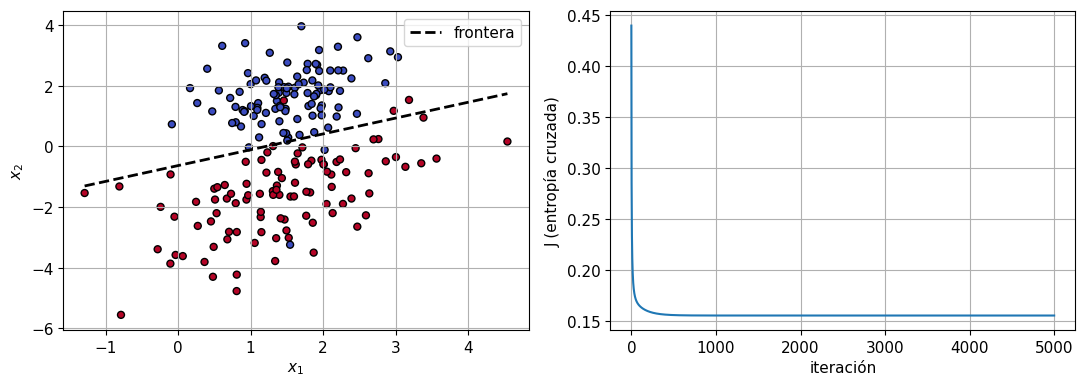

In [ ]:
# Frontera de decisión:  theta_0 + theta_1 x1 + theta_2 x2 = 0
xx = np.linspace(Xc[:, 0].min(), Xc[:, 0].max(), 50)
yy = -(Theta_log[0] + Theta_log[1] * xx) / Theta_log[2]

plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k", s=25)
plt.plot(xx, yy, "k--", lw=2, label="frontera")
plt.ylim(Xc[:, 1].min() - 0.5, Xc[:, 1].max() + 0.5)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend()

plt.subplot(122)
plt.plot(hist_log); plt.xlabel("iteración"); plt.ylabel("J (entropía cruzada)")
plt.tight_layout(); plt.show()

---
# Parte 7 — Multiclase y regularización

**Multiclase.** Con $K>2$ clases hay dos estrategias:

* *Uno contra todos*: se entrenan $K$ clasificadores binarios (clase $k$ vs. el resto) y se elige el de mayor probabilidad.
* *Softmax*: se generaliza la sigmoide a $P(y=k\mid X)=\dfrac{e^{\Theta_k^TX}}{\sum_j e^{\Theta_j^TX}}$ y se entrena un solo modelo.

**Regularización.** Para controlar el sobreajuste se penalizan los parámetros grandes:

$$J_{reg}(\Theta)=J(\Theta)+\frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2
\qquad\Longrightarrow\qquad
\theta_j := \theta_j\left(1-\alpha\frac{\lambda}{m}\right)-\frac{\alpha}{m}\sum_{i=1}^{m}\left(h_\Theta(X^{(i)})-y^{(i)}\right)x_j^{(i)}$$

El intercepto $\theta_0$ **no** se regulariza. En `scikit-learn` el parámetro es `C` $=1/\lambda$: **C pequeño = mucha regularización**.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

iris = load_iris()
Xi, yi = iris.data, iris.target
Xtr, Xte, ytr, yte = train_test_split(Xi, yi, test_size=0.3, stratify=yi, random_state=42)

modelo = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
modelo.fit(Xtr, ytr)
print("Exactitud entrenamiento:", round(modelo.score(Xtr, ytr), 3))
print("Exactitud prueba       :", round(modelo.score(Xte, yte), 3))

flor = np.array([[5.9, 3.0, 5.1, 1.8]])
p = modelo.predict_proba(flor)[0]
for nombre, prob in zip(iris.target_names, p):
    print(f"  P({nombre:<12}) = {prob:.3f}")

Exactitud entrenamiento: 0.981
Exactitud prueba       : 0.911
  P(setosa      ) = 0.005
  P(versicolor  ) = 0.341
  P(virginica   ) = 0.653


### ✏️ Ejercicio 7.1 — El efecto de la regularización

Barra `C` en escala logarítmica y grafique la exactitud en entrenamiento y en prueba.

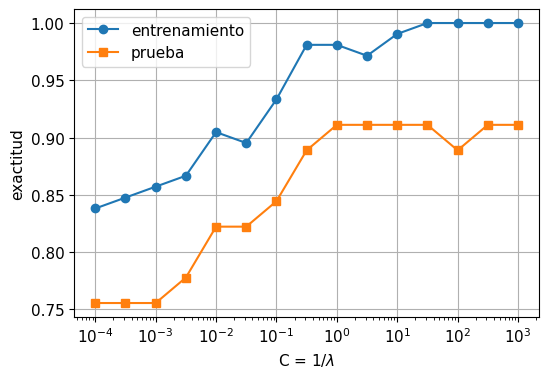

In [ ]:
Cs = np.logspace(-4, 3, 15)

acc_tr, acc_te = [], []

for c in Cs:

    m_ = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=c, max_iter=1000)
    )

    m_.fit(Xtr, ytr)

    acc_tr.append(m_.score(Xtr, ytr))   # exactitud entrenamiento
    acc_te.append(m_.score(Xte, yte))   # exactitud prueba

plt.figure(figsize=(6, 4))

plt.semilogx(Cs, acc_tr, "o-", label="entrenamiento")
plt.semilogx(Cs, acc_te, "s-", label="prueba")

plt.xlabel("C = 1/$\\lambda$")
plt.ylabel("exactitud")
plt.legend()
plt.show()

In [ ]:
# ✅ Checkpoint 7.1
assert len(acc_tr) == len(Cs) and len(acc_te) == len(Cs), "faltan valores en el barrido"
assert acc_tr[0] < acc_tr[-1], "con C muy pequeño el modelo debe quedar subajustado"
print(f"Correcto ✔  mejor C = {Cs[int(np.argmax(acc_te))]:.4g}  "
      f"(exactitud de prueba {max(acc_te):.3f})")

Correcto ✔  mejor C = 1  (exactitud de prueba 0.911)



## Preguntas de análisis (para el informe)

1. ¿Por qué el error cuadrático produce una superficie de coste convexa mientras que aplicado a la sigmoide no lo hace?
2. Usted entrena con $\alpha=0.01$ durante 100 iteraciones y el coste baja muy poco. Enumere dos causas posibles y cómo distinguirlas.
3. Con $n=50\,000$ características, ¿usaría la ecuación normal? Justifique con la tabla de la Parte 5.
4. En la gráfica del Ejercicio 7.1, ¿qué región corresponde a subajuste y cuál a sobreajuste? ¿Qué valor de $C$ reportaría y por qué?

## Retos opcionales

* **A. Otras métricas.** Generalice el coste a $J=\frac{1}{pm}\sum_i (h_\theta(x^{(i)})-y^{(i)})^p$. Compare los $\Theta$ obtenidos con $p=1,2,3$ sobre los datos de la Parte 1 y explique cuál es más robusto a valores atípicos (agregue algunos y compruébelo).
* **B. Curvas de aprendizaje.** Grafique $J_{train}$ y $J_{test}$ en función del tamaño del conjunto de entrenamiento para el modelo de la Parte 5. ¿Qué diagnóstico sugieren?
* **C. Clasificación de púlsares.** Con el dataset [HTRU2](https://archive.ics.uci.edu/ml/datasets/HTRU2), construya un clasificador logístico: divida en train/test, entrene, analice las curvas de aprendizaje y aplique regularización. Discuta por qué la exactitud es una métrica engañosa en un dataset tan desbalanceado.

## Referencias

1. Stanford CS229 — <http://cs229.stanford.edu/syllabus.html>
2. A. Ng, *Machine Learning* (Coursera), semanas 1–3.
3. A. Géron, *Hands-On Machine Learning*, cap. 4.
4. Documentación de scikit-learn — <https://scikit-learn.org/stable/>

## Respuestas a las preguntas de análisis

### 1. ¿Por qué el error cuadrático produce una superficie de coste convexa mientras que aplicado a la sigmoide no lo hace?

En regresión lineal, la hipótesis está dada por

$$
h_\Theta(X)=X\Theta,
$$

y la función de coste de error cuadrático es

$$
J(\Theta)=\frac{1}{2m}\|X\Theta-y\|^2.
$$

Esta función es cuadrática respecto a los parámetros $\Theta$. Su matriz Hessiana es

$$
\nabla^2J(\Theta)=\frac{1}{m}X^TX,
$$

la cual es semidefinida positiva, ya que para cualquier vector $v$ se cumple

$$
v^TX^TXv=\|Xv\|^2\geq0.
$$

Por esta razón, la superficie de coste de la regresión lineal es convexa.

En regresión logística, en cambio, la hipótesis es

$$
h_\Theta(X)=\sigma(X\Theta).
$$

Si se aplica directamente el error cuadrático,

$$
J(\Theta)=\frac{1}{2m}\sum_{i=1}^{m}
\left[\sigma(\Theta^TX^{(i)})-y^{(i)}\right]^2,
$$

la composición con la función sigmoide introduce una dependencia no lineal respecto a los parámetros y la función resultante no garantiza convexidad. Por esta razón se utiliza la entropía cruzada,

$$
J(\Theta)=
-\frac{1}{m}\sum_{i=1}^{m}
\left[
y^{(i)}\log h_\Theta(X^{(i)})
+
(1-y^{(i)})\log(1-h_\Theta(X^{(i)}))
\right],
$$

que en la regresión logística estándar produce una función de coste convexa y facilita la búsqueda del mínimo global.


### 2. Usted entrena con $\alpha=0.01$ durante 100 iteraciones y el coste baja muy poco. Enumere dos causas posibles y cómo distinguirlas.

Una primera causa posible es que la tasa de aprendizaje $\alpha=0.01$ sea demasiado pequeña. En este caso, las actualizaciones de los parámetros,

$$
\Theta^{(k+1)}
=
\Theta^{(k)}-\alpha\nabla J(\Theta^{(k)}),
$$

son muy pequeñas y el algoritmo avanza lentamente hacia el mínimo. Esto puede identificarse observando la curva del coste: si $J(\Theta)$ disminuye de manera estable pero muy lentamente, se puede probar con valores mayores de $\alpha$ y verificar si la convergencia se acelera sin producir oscilaciones o divergencia.

Una segunda causa es que las características tengan escalas muy diferentes. Esto puede generar una superficie de coste mal condicionada y hacer que el descenso de gradiente avance de manera poco eficiente. Para comprobarlo se pueden inspeccionar las escalas de las variables y posteriormente estandarizarlas mediante

$$
x_j'=\frac{x_j-\mu_j}{\sigma_j}.
$$

Si después de la estandarización el coste disminuye considerablemente más rápido utilizando el mismo algoritmo, entonces el problema estaba relacionado con el escalamiento de las características.


### 3. Con $n=50000$ características, ¿usaría la ecuación normal? Justifique con la tabla de la Parte 5.

No utilizaría la ecuación normal de forma directa para un problema con $n=50000$ características. La ecuación normal requiere resolver el sistema

$$
(X^TX)\Theta=X^Ty.
$$

Con 50000 características, la matriz $X^TX$ tendría aproximadamente

$$
50000\times50000=2.5\times10^9
$$

elementos. Si se almacena como una matriz densa utilizando números de 64 bits, solamente esta matriz requeriría aproximadamente 20 GB de memoria.

Además, como se discutió en la Parte 5, la solución directa del sistema tiene un coste computacional que puede crecer aproximadamente como

$$
O(n^3),
$$

por lo que resulta poco conveniente cuando el número de características es muy grande. En este caso sería preferible utilizar un método iterativo, como descenso de gradiente u otros algoritmos de optimización, que eviten construir y resolver directamente un sistema de estas dimensiones.


### 4. En la gráfica del Ejercicio 7.1, ¿qué región corresponde a subajuste y cuál a sobreajuste? ¿Qué valor de $C$ reportaría y por qué?

En `scikit-learn`, el parámetro $C$ se relaciona inversamente con la intensidad de la regularización:

$$
C=\frac{1}{\lambda}.
$$

Por lo tanto, valores pequeños de $C$ corresponden a valores grandes de $\lambda$ y, en consecuencia, a una regularización fuerte. En esta región el modelo puede quedar excesivamente restringido, produciendo bajas exactitudes tanto en entrenamiento como en prueba. Esta situación corresponde al **subajuste**.

Por otro lado, al aumentar $C$, la regularización disminuye y el modelo adquiere mayor flexibilidad. Si para valores grandes de $C$ la exactitud de entrenamiento continúa aumentando o permanece muy alta, mientras que la exactitud de prueba deja de mejorar o comienza a disminuir, se presenta una señal de **sobreajuste**. En este caso, el modelo se está ajustando cada vez más a los datos de entrenamiento sin mejorar su capacidad de generalización.

De acuerdo con el barrido realizado en el Ejercicio 7.1, reportaría el valor de $C$ que produjo la mayor exactitud en el conjunto de prueba:

$$
C^*=
C_{\arg\max(\mathrm{accuracy}_{test})}.
$$

En nuestro código este valor se obtiene mediante

`Cs[int(np.argmax(acc_te))]`.

Por tanto, reportaría **$C=$ [VALOR OBTENIDO]**, con una exactitud de prueba de **[EXACTITUD OBTENIDA]**, debido a que fue el valor que presentó el mejor desempeño sobre los datos no utilizados durante el entrenamiento entre los valores de $C$ evaluados.

Si en la gráfica la exactitud de prueba no disminuye para valores grandes de $C$, no se puede afirmar que exista un sobreajuste evidente en el rango estudiado. En ese caso, los valores grandes de $C$ corresponden a una región con menor regularización y mayor riesgo de sobreajuste, pero la gráfica no muestra evidencia clara de que este se haya producido.

In [ ]:
# Retos opcionales

p=1 sin outliers -> theta0=0.2054, theta1=0.4909
p=2 sin outliers -> theta0=0.2048, theta1=0.4874
p=3 sin outliers -> theta0=0.2032, theta1=0.4887
p=1 con outliers -> theta0=0.2091, theta1=0.4786
p=2 con outliers -> theta0=0.2313, theta1=0.4283
p=3 con outliers -> theta0=0.3431, theta1=0.1588


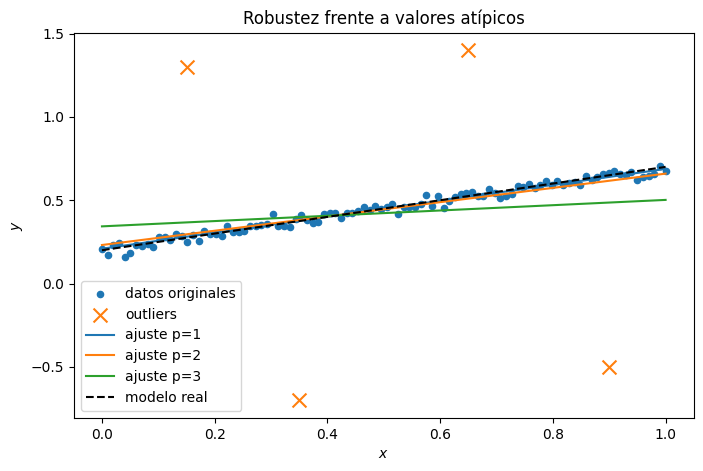


Cambio en los parámetros debido a los outliers:
p=1: cambio = 0.0128
p=2: cambio = 0.0648
p=3: cambio = 0.3583


In [2]:
# RETO A — Otras métricas y robustez a outliers

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng_A = np.random.default_rng(42)

# Generamos nuevamente los datos de la Parte 1
m = 100

X_A = np.linspace(0, 1, m)

theta_real = (0.2, 0.5)

y_A = (
    theta_real[0]
    + theta_real[1] * X_A
    + rng_A.normal(0, 0.03, m)
)


# Hipótesis lineal
def H_A(X, t0, t1):
    return t0 + t1 * X


# Coste generalizado
def J_p(Theta, X, y, p):
    t0, t1 = Theta

    pred = H_A(X, t0, t1)

    error = np.abs(pred - y)

    return np.mean(error**p) / p


# Ajuste numérico
def ajustar_p(X, y, p):

    # Powell funciona bien incluso para p=1,
    # donde el valor absoluto no es diferenciable en cero
    resultado = minimize(
        lambda Theta: J_p(Theta, X, y, p),
        x0=np.array([0.0, 0.0]),
        method="Powell"
    )

    return resultado.x


# --------------------------------------------------
# 1. Ajustes SIN valores atípicos
# --------------------------------------------------

thetas_limpios = {}

for p in [1, 2, 3]:

    thetas_limpios[p] = ajustar_p(X_A, y_A, p)

    print(
        f"p={p} sin outliers -> "
        f"theta0={thetas_limpios[p][0]:.4f}, "
        f"theta1={thetas_limpios[p][1]:.4f}"
    )


# --------------------------------------------------
# 2. Agregamos valores atípicos
# --------------------------------------------------

X_out = np.array([0.15, 0.35, 0.65, 0.90])

y_out = np.array([1.30, -0.70, 1.40, -0.50])


X_A_out = np.concatenate([X_A, X_out])

y_A_out = np.concatenate([y_A, y_out])


# --------------------------------------------------
# 3. Ajustes CON valores atípicos
# --------------------------------------------------

thetas_out = {}

for p in [1, 2, 3]:

    thetas_out[p] = ajustar_p(
        X_A_out,
        y_A_out,
        p
    )

    print(
        f"p={p} con outliers -> "
        f"theta0={thetas_out[p][0]:.4f}, "
        f"theta1={thetas_out[p][1]:.4f}"
    )


# --------------------------------------------------
# 4. Gráfica
# --------------------------------------------------

xx = np.linspace(0, 1, 200)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_A,
    y_A,
    s=20,
    label="datos originales"
)

plt.scatter(
    X_out,
    y_out,
    marker="x",
    s=100,
    label="outliers"
)

for p in [1, 2, 3]:

    t0, t1 = thetas_out[p]

    plt.plot(
        xx,
        H_A(xx, t0, t1),
        label=f"ajuste p={p}"
    )

plt.plot(
    xx,
    theta_real[0] + theta_real[1] * xx,
    "k--",
    label="modelo real"
)

plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Robustez frente a valores atípicos")
plt.legend()
plt.show()


# --------------------------------------------------
# 5. Cuánto cambian los parámetros por los outliers
# --------------------------------------------------

print("\nCambio en los parámetros debido a los outliers:")

for p in [1, 2, 3]:

    cambio = np.linalg.norm(
        thetas_out[p] - thetas_limpios[p]
    )

    print(
        f"p={p}: cambio = {cambio:.4f}"
    )

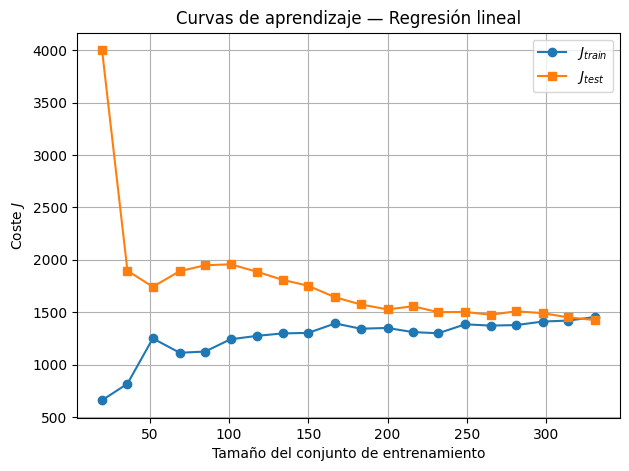

In [3]:
# RETO B — Curvas de aprendizaje

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split


# --------------------------------------------------
# 1. Cargar datos de diabetes
# --------------------------------------------------

datos = load_diabetes()

X_B = datos.data
y_B = datos.target


# --------------------------------------------------
# 2. Funciones necesarias
# --------------------------------------------------

def agregar_sesgo_B(Xf):

    Xf = np.asarray(Xf, dtype=float)

    if Xf.ndim == 1:
        Xf = Xf.reshape(-1, 1)

    return np.hstack([
        np.ones((Xf.shape[0], 1)),
        Xf
    ])


def h_lin_B(Theta, Xb):
    return Xb @ Theta


def J_lin_B(Theta, Xb, y):

    r = h_lin_B(Theta, Xb) - y

    return (r @ r) / (2 * len(y))


def ecuacion_normal_B(Xb, y):

    A = Xb.T @ Xb
    b = Xb.T @ y

    # lstsq es más robusto que solve si la matriz no es invertible
    Theta = np.linalg.lstsq(A, b, rcond=None)[0]

    return Theta


# --------------------------------------------------
# 3. División train/test
# --------------------------------------------------

Xtr_B, Xte_B, ytr_B, yte_B = train_test_split(
    X_B,
    y_B,
    test_size=0.25,
    random_state=42
)


# --------------------------------------------------
# 4. Tamaños de entrenamiento
# --------------------------------------------------

tamanos = np.linspace(
    20,
    len(Xtr_B),
    20,
    dtype=int
)


J_train_B = []
J_test_B = []


# --------------------------------------------------
# 5. Entrenar con distintos tamaños
# --------------------------------------------------

for n_train in tamanos:

    X_sub = Xtr_B[:n_train]
    y_sub = ytr_B[:n_train]

    X_sub_b = agregar_sesgo_B(X_sub)
    X_test_b = agregar_sesgo_B(Xte_B)

    Theta_sub = ecuacion_normal_B(
        X_sub_b,
        y_sub
    )

    Jtr = J_lin_B(
        Theta_sub,
        X_sub_b,
        y_sub
    )

    Jte = J_lin_B(
        Theta_sub,
        X_test_b,
        yte_B
    )

    J_train_B.append(Jtr)
    J_test_B.append(Jte)


# --------------------------------------------------
# 6. Gráfica
# --------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    tamanos,
    J_train_B,
    "o-",
    label="$J_{train}$"
)

plt.plot(
    tamanos,
    J_test_B,
    "s-",
    label="$J_{test}$"
)

plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Coste $J$")
plt.title("Curvas de aprendizaje — Regresión lineal")
plt.legend()
plt.grid(True)

plt.show()

In [4]:
!pip -q install ucimlrepo

In [5]:
# RETO C — Clasificación de púlsares HTRU2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    train_test_split,
    learning_curve
)

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


# --------------------------------------------------
# 1. Cargar dataset
# --------------------------------------------------

htru2 = fetch_ucirepo(id=372)

X_C = htru2.data.features
y_C = htru2.data.targets.squeeze()


print("Forma de X:", X_C.shape)
print("Forma de y:", y_C.shape)

print("\nDistribución de clases:")
print(y_C.value_counts())

print("\nProporciones:")
print(y_C.value_counts(normalize=True))

Forma de X: (17898, 8)
Forma de y: (17898,)

Distribución de clases:
class
0    16259
1     1639
Name: count, dtype: int64

Proporciones:
class
0    0.908426
1    0.091574
Name: proportion, dtype: float64


In [6]:
# --------------------------------------------------
# 2. División train/test
# --------------------------------------------------

Xtr_C, Xte_C, ytr_C, yte_C = train_test_split(
    X_C,
    y_C,
    test_size=0.25,
    random_state=42,
    stratify=y_C
)

print("Train:", Xtr_C.shape)
print("Test :", Xte_C.shape)

Train: (13423, 8)
Test : (4475, 8)


In [7]:
# --------------------------------------------------
# 3. Modelo logístico
# --------------------------------------------------

modelo_C = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,
        max_iter=5000
    )
)

modelo_C.fit(Xtr_C, ytr_C)


pred_C = modelo_C.predict(Xte_C)

prob_C = modelo_C.predict_proba(Xte_C)[:, 1]

In [8]:
# --------------------------------------------------
# 4. Métricas
# --------------------------------------------------

acc_C = accuracy_score(yte_C, pred_C)

prec_C = precision_score(yte_C, pred_C)

rec_C = recall_score(yte_C, pred_C)

f1_C = f1_score(yte_C, pred_C)

auc_C = roc_auc_score(yte_C, prob_C)


print("Accuracy :", round(acc_C, 4))
print("Precision:", round(prec_C, 4))
print("Recall   :", round(rec_C, 4))
print("F1-score :", round(f1_C, 4))
print("ROC-AUC  :", round(auc_C, 4))


print("\nReporte de clasificación:\n")
print(classification_report(yte_C, pred_C))

Accuracy : 0.9794
Precision: 0.9441
Recall   : 0.8244
F1-score : 0.8802
ROC-AUC  : 0.974

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4065
           1       0.94      0.82      0.88       410

    accuracy                           0.98      4475
   macro avg       0.96      0.91      0.93      4475
weighted avg       0.98      0.98      0.98      4475



In [9]:
# --------------------------------------------------
# 5. Matriz de confusión
# --------------------------------------------------

cm_C = confusion_matrix(yte_C, pred_C)

print("Matriz de confusión:")

print(cm_C)


tn, fp, fn, tp = cm_C.ravel()


print("\nTN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

Matriz de confusión:
[[4045   20]
 [  72  338]]

TN = 4045
FP = 20
FN = 72
TP = 338


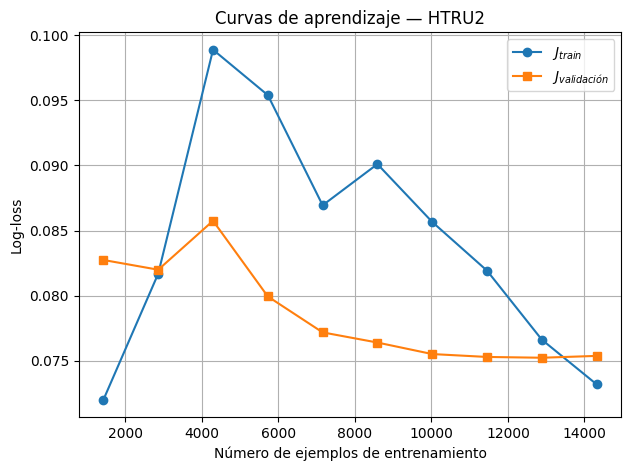

In [10]:
# --------------------------------------------------
# 6. Curvas de aprendizaje
# --------------------------------------------------

modelo_lc_C = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1.0,
        max_iter=5000
    )
)


train_sizes_C, train_scores_C, val_scores_C = learning_curve(
    modelo_lc_C,
    X_C,
    y_C,
    cv=5,
    scoring="neg_log_loss",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)


# sklearn devuelve log-loss negativa
Jtrain_C = -train_scores_C.mean(axis=1)

Jval_C = -val_scores_C.mean(axis=1)


plt.figure(figsize=(7, 5))

plt.plot(
    train_sizes_C,
    Jtrain_C,
    "o-",
    label="$J_{train}$"
)

plt.plot(
    train_sizes_C,
    Jval_C,
    "s-",
    label="$J_{validación}$"
)

plt.xlabel("Número de ejemplos de entrenamiento")
plt.ylabel("Log-loss")
plt.title("Curvas de aprendizaje — HTRU2")
plt.legend()
plt.grid(True)

plt.show()

In [11]:
# --------------------------------------------------
# 7. Efecto de la regularización
# --------------------------------------------------

Cs_C = np.logspace(-4, 3, 15)


accs_C = []
precs_C = []
recs_C = []
f1s_C = []
aucs_C = []


for c in Cs_C:

    modelo = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=c,
            max_iter=5000
        )
    )

    modelo.fit(Xtr_C, ytr_C)

    pred = modelo.predict(Xte_C)

    prob = modelo.predict_proba(Xte_C)[:, 1]


    accs_C.append(
        accuracy_score(yte_C, pred)
    )

    precs_C.append(
        precision_score(yte_C, pred)
    )

    recs_C.append(
        recall_score(yte_C, pred)
    )

    f1s_C.append(
        f1_score(yte_C, pred)
    )

    aucs_C.append(
        roc_auc_score(yte_C, prob)
    )

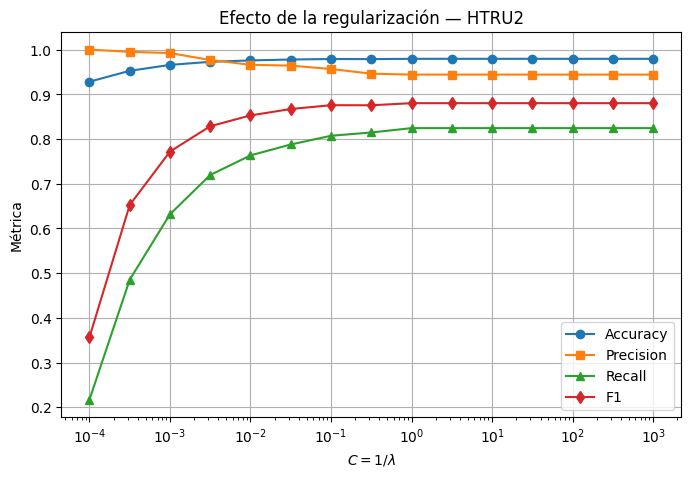

In [12]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    Cs_C,
    accs_C,
    "o-",
    label="Accuracy"
)

plt.semilogx(
    Cs_C,
    precs_C,
    "s-",
    label="Precision"
)

plt.semilogx(
    Cs_C,
    recs_C,
    "^-",
    label="Recall"
)

plt.semilogx(
    Cs_C,
    f1s_C,
    "d-",
    label="F1"
)

plt.xlabel("$C = 1/\\lambda$")
plt.ylabel("Métrica")
plt.title("Efecto de la regularización — HTRU2")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
i_best_C = np.argmax(f1s_C)

best_C = Cs_C[i_best_C]


print("Mejor C según F1:", best_C)

print(
    "Accuracy :",
    round(accs_C[i_best_C], 4)
)

print(
    "Precision:",
    round(precs_C[i_best_C], 4)
)

print(
    "Recall   :",
    round(recs_C[i_best_C], 4)
)

print(
    "F1-score :",
    round(f1s_C[i_best_C], 4)
)

print(
    "ROC-AUC  :",
    round(aucs_C[i_best_C], 4)
)

Mejor C según F1: 1.0
Accuracy : 0.9794
Precision: 0.9441
Recall   : 0.8244
F1-score : 0.8802
ROC-AUC  : 0.974
